In [2]:
# =========================================================
# Project Title: Credit Risk Prediction & Default Analysis
# Course: Machine Learning for Business Analysis
# =========================================================

# =========================
# Step 1: Import Libraries
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

Dataset Loaded Successfully

First 5 Rows:
   observation_id  checking_balance  months_loan_duration credit_history  \
0               0             -43.0                     6       critical   
1               1              75.0                    48         repaid   
2               2               NaN                    12       critical   
3               3             -32.0                    42         repaid   
4               4             -23.0                    24        delayed   

     purpose  amount  savings_balance employment_length  installment_rate  \
0   radio/tv    1169              NaN          13 years                 4   
1   radio/tv    5951             89.0           2 years                 2   
2  education    2096             24.0           5 years                 2   
3  furniture    7882              9.0           5 years                 2   
4  car (new)    4870             43.0           3 years                 3   

  personal_status other_debtors resid

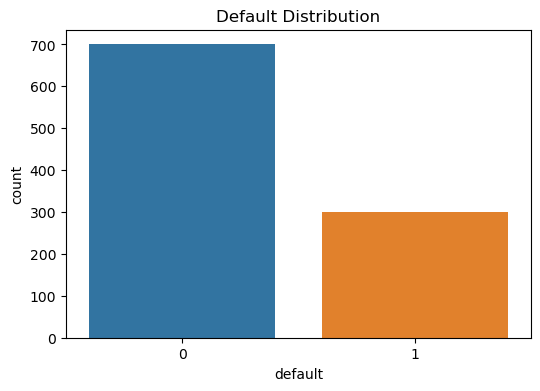

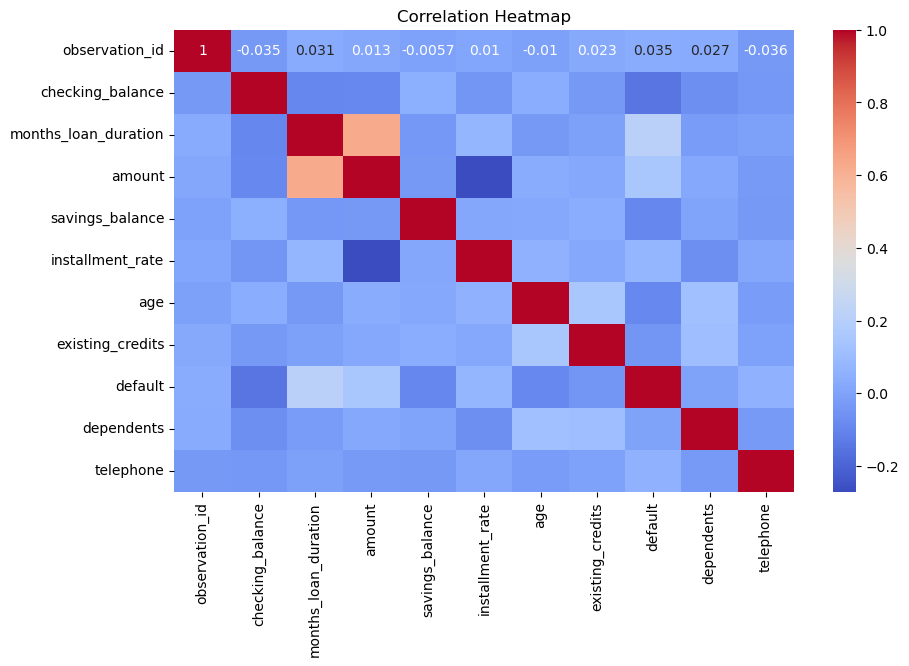

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


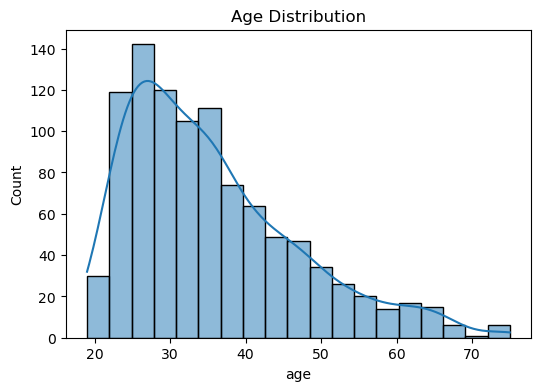


Numerical Columns:
['checking_balance', 'months_loan_duration', 'amount', 'savings_balance', 'installment_rate', 'age', 'existing_credits', 'dependents', 'telephone']

Categorical Columns:
['credit_history', 'purpose', 'employment_length', 'personal_status', 'other_debtors', 'residence_history', 'property', 'installment_plan', 'housing', 'foreign_worker', 'job', 'gender']

Train Shape: (800, 21)
Test Shape: (200, 21)

Model: Logistic Regression
Accuracy  : 0.7500
Recall    : 0.3833
F1 Score  : 0.4792
AUC-ROC   : 0.7168

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.91      0.84       140
           1       0.64      0.38      0.48        60

    accuracy                           0.75       200
   macro avg       0.71      0.65      0.66       200
weighted avg       0.73      0.75      0.73       200

Confusion Matrix:
[[127  13]
 [ 37  23]]

Model: Decision Tree
Accuracy  : 0.6500
Recall    : 0.5333
F1 Score  : 0.4776
AUC

In [3]:

# for clean output
pd.set_option("display.max_columns", None)


# =========================
# Step 2: Load Dataset
# =========================

df = pd.read_csv("credit.csv")

print("Dataset Loaded Successfully\n")

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)


# =========================
# Step 3: Basic Information
# =========================

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


# =========================
# Step 4: Exploratory Data Analysis (EDA)
# =========================

# Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="default", data=df)
plt.title("Default Distribution")
plt.show()

# Correlation Heatmap (only numeric columns)
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["age"], kde=True)
plt.title("Age Distribution")
plt.show()


# =========================
# Step 5: Data Preprocessing
# =========================

# Remove unnecessary ID column
if "observation_id" in df.columns:
    df.drop("observation_id", axis=1, inplace=True)

# Features and Target
X = df.drop("default", axis=1)
y = df["default"]

# Separate numerical and categorical columns
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)


# Numerical Pipeline
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical Pipeline
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Full Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])


# =========================
# Step 6: Train Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


# =========================
# Step 7: Model Training
# =========================

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "SVM": SVC(probability=True, random_state=42)
}


# =========================
# Step 8: Model Evaluation
# =========================

results = []

for name, model in models.items():

    print("\n==================================================")
    print(f"Model: {name}")
    print("==================================================")

    # Create Pipeline
    final_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train Model
    final_pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = final_pipeline.predict(X_test)
    y_prob = final_pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)

    report = classification_report(y_test, y_pred, output_dict=True)

    recall = report["1"]["recall"]      # Recall for Default = 1
    f1 = report["1"]["f1-score"]        # F1 for Default = 1

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"AUC-ROC   : {auc_score:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Save Results
    results.append([name, accuracy, recall, f1, auc_score])


# =========================
# Step 9: Final Comparison
# =========================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Recall",
        "F1 Score",
        "AUC-ROC"
    ]
)

print("\n================ FINAL MODEL COMPARISON ================")
print(results_df.sort_values(by="AUC-ROC", ascending=False))


# =========================
# Step 10: Best Model
# =========================

best_model = results_df.sort_values(
    by="AUC-ROC",
    ascending=False
).iloc[0]

print("\n================ BEST MODEL ================")
print(best_model)

print(f"""
Business Recommendation:

Best model selected based on AUC-ROC, Recall and F1-Score is:
{best_model['Model']}

Why?
Because in Credit Risk Prediction, missing a defaulter
(False Negative) is very costly for the bank.

Therefore Recall + F1 Score + AUC-ROC are more important
than only Accuracy.
""")